<a href="https://colab.research.google.com/github/zastrozhnayayana/nn-zero-to-hero-notes/blob/main/makemore_batchnorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    # self.weight = torch.randn((fan_in, fan_out)) / (fan_in ** 0.5)
    self.weight = torch.zeros((fan_in, fan_out))
    self.bias = torch.zeros(fan_out) if bias is True else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-05, momentum=0.1):
    self.training = True
    self.momentum = momentum
    self.eps = eps
    self.mean_running = torch.zeros(dim)
    self.var_running = torch.ones(dim)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.mean_running
      xvar = self.var_running

    self.out = self.gamma * (x - xmean) / torch.sqrt(xvar + self.eps)  + self.beta

    if self.training:
      with torch.no_grad():
        self.mean_running = (1 - self.momentum) * self.mean_running + self.momentum * self.mean_running
        self.var_running = (1 - self.momentum) * self.var_running + self.momentum * self.var_running

    return self.out

  def parameters(self):
      return [self.gamma] + [self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-14 08:57:47--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.26’

names.txt.26        100%[===================>] 222.80K  --.-KB/s    in 0.003s  

2026-05-14 08:57:47 (64.8 MB/s) - ‘names.txt.26’ saved [228145/228145]



In [ ]:
stoi = {chr(i): i - ord('a') + 1 for i in range(ord('a'), ord('z') + 1)} # 'a' -> 1 ... '.' -> 0
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [ ]:
# words = open('names.txt').read() # читает всё в одну строку (в том числе в ней есть '\n')
words = open('names.txt').read().splitlines() # массив из строк

In [ ]:
len(words)

32033

In [ ]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
n_emb = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility
vocab_size = 27
C = torch.randn((vocab_size, n_emb),            generator=g)  # С[lt] = в какой 10-мерный вектор переходит буква lt

In [ ]:
# layers = [Linear(n_emb * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#           Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#           Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#           Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#           Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#           Linear(          n_hidden, vocab_size), BatchNorm1d(vocab_size)]
layers = [Linear(n_emb * block_size, n_hidden), Tanh(),
          # Linear(          n_hidden, n_hidden), Tanh(),
          # Linear(          n_hidden, n_hidden), Tanh(),
          # Linear(          n_hidden, n_hidden), Tanh(),
          # Linear(          n_hidden, n_hidden), Tanh(),
          Linear(          n_hidden, vocab_size)]


In [ ]:
print(C.shape)
for layer in layers:
  if isinstance(layer, Linear):
    print(layer.weight.shape)

torch.Size([27, 10])
torch.Size([30, 100])
torch.Size([100, 27])


In [ ]:
with torch.no_grad():
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3
  # layers[-1].gamma *= 0.01
  # layers[-1].weight *= 0.01

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
  p.requires_grad = True

In [ ]:
parameters

[tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
          -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01],
         [-4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
           2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01],
         [ 9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
           2.4968e+00,  2.4448e+00, -6.7006e-01, -1.2199e+00,  3.0314e-01],
         [-1.0725e+00,  7.2762e-01,  5.1114e-02,  1.3095e+00, -8.0220e-01,
          -8.5042e-01, -1.8068e+00,  1.2523e+00, -1.2256e+00,  1.2165e+00],
         [-9.6478e-01, -2.3211e-01, -3.4762e-01,  3.3244e-01, -1.3263e+00,
           1.1224e+00,  5.9641e-01,  4.5846e-01,  5.4011e-02, -1.7400e+00],
         [ 1.1560e-01,  8.0319e-01,  5.4108e-01, -1.1646e+00,  1.4756e-01,
          -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01, -7.8305e-01],
         [ 1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,  9.3743e-01,
          -8.8303e-

In [ ]:
max_steps = 200000
batch_size = 32
ud = []

for k in range(max_steps):
  X, Y = Xtr, Ytr
  ix = torch.randint(0, X.shape[0], (batch_size,))
  emb = C[X[ix]].view(-1, n_emb * block_size)

  #forward pass
  x = emb
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Y[ix]) # считаем ошибку


  #backward pass
  for layer in layers:
    layer.out.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  lr = 0.1 if k < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad
  if k % 10000 == 0:
    print(loss.item())
  if k > 1000:
    break

  ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

3.295837163925171


In [ ]:
for p in parameters:
    print(p)


tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01],
        [-4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01],
        [ 9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
          2.4968e+00,  2.4448e+00, -6.7006e-01, -1.2199e+00,  3.0314e-01],
        [-1.0725e+00,  7.2762e-01,  5.1114e-02,  1.3095e+00, -8.0220e-01,
         -8.5042e-01, -1.8068e+00,  1.2523e+00, -1.2256e+00,  1.2165e+00],
        [-9.6478e-01, -2.3211e-01, -3.4762e-01,  3.3244e-01, -1.3263e+00,
          1.1224e+00,  5.9641e-01,  4.5846e-01,  5.4011e-02, -1.7400e+00],
        [ 1.1560e-01,  8.0319e-01,  5.4108e-01, -1.1646e+00,  1.4756e-01,
         -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01, -7.8305e-01],
        [ 1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,  9.3743e-01,
         -8.8303e-01,  1.7457e+0

layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

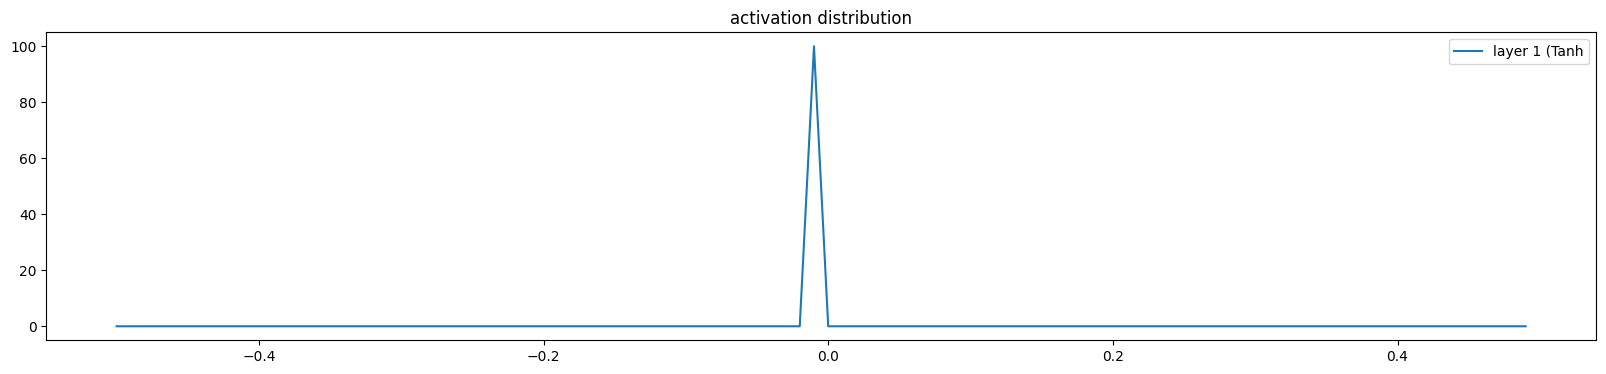

In [ ]:
# график показывает как много таких значений встречается на выходе из данного слоя tanh
# если корнцы слишком выскоие - плохо, значит tanh перенасыщается
# параллельно с этим ведём статистику (среднее значение, стандартное отклонение (насколько большие числа), процент значений, в которых tanh насыщен)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.000000, std 0.000000e+00


Text(0.5, 1.0, 'gradient distribution')

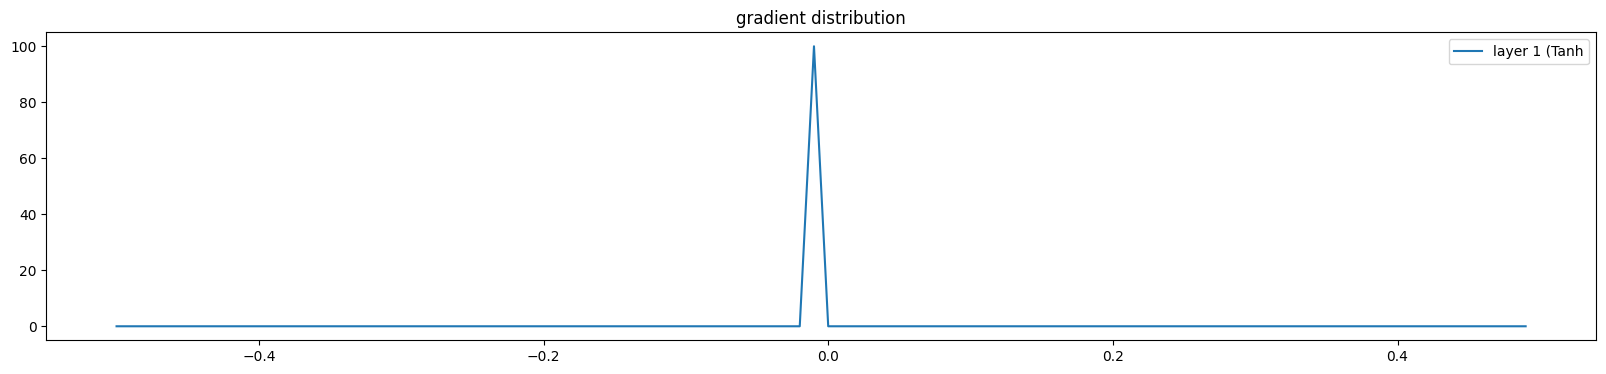

In [ ]:
# то же самое для значений градиентов на выходе из tanh
# плохо, если значения становятся слишком маленькими или слишком большими после прохождения через слои NN
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

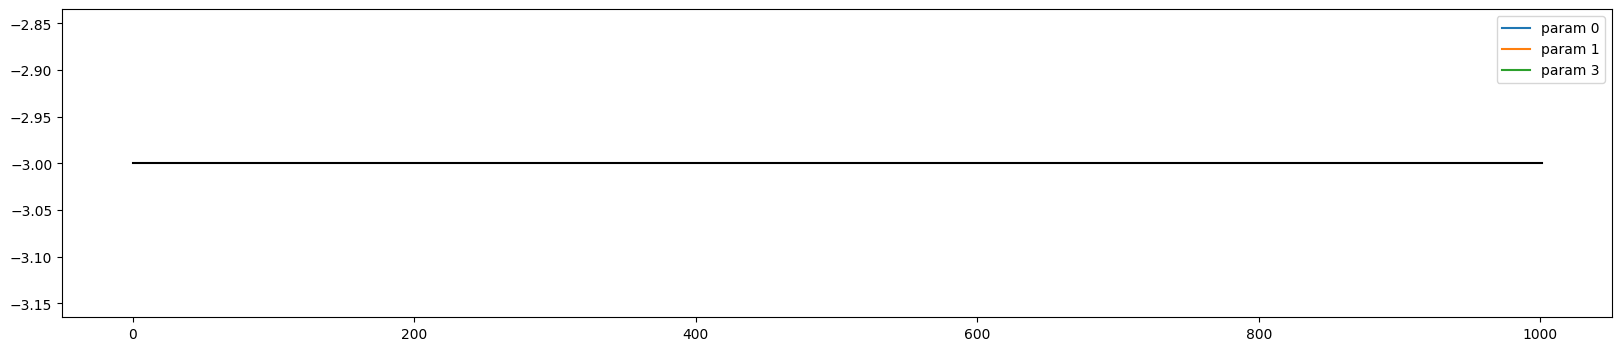

In [ ]:
# смотрим насколько сильные изменения мы делаем к значениям весов в NN
# lr * p.grad.std() / p.data.std() должно быть примерно 1e-3
# слева на право меняется время (итерации)
# значения отношения (логарифма отношения по основанию 10) для выхода каждого tanh слоя
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
